In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("job_salary_prediction_dataset1.csv")

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734


In [4]:
df.shape

(250000, 10)

In [5]:
df.isnull().sum()

job_title              0
experience_years     602
education_level      515
skills_count         826
industry               0
company_size         960
location            1069
remote_work            0
certifications       575
salary                 0
dtype: int64

In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,249398.000000,249174.000000,249425.000000,250000.000000
mean,10.006247,9.999133,2.494197,117510.722696
std,6.060365,5.463778,1.703118,38385.455248
min,0.000000,1.000000,0.000000,14139.000000
25%,5.000000,5.000000,1.000000,89666.750000
50%,10.000000,10.000000,3.000000,117504.000000
75%,15.000000,15.000000,4.000000,145491.500000
max,20.000000,19.000000,5.000000,220977.000000


In [7]:
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].mean())


#### df.describe()

In [8]:
df['skills_count'].dtype

dtype('float64')

249174


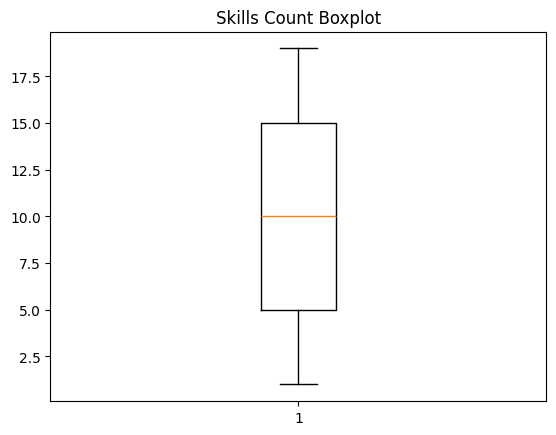

In [9]:
import matplotlib.pyplot as plt

# Remove null values
data = df['skills_count'].dropna()

# Check if data exists
print(len(data))   # should not be 0

plt.figure()

plt.boxplot(data)

plt.title("Skills Count Boxplot")

plt.show()

In [10]:
print(data.head())
print(data.describe())

0     2.0
1    17.0
2     4.0
3    13.0
4     7.0
Name: skills_count, dtype: float64
count    249174.000000
mean          9.999133
std           5.463778
min           1.000000
25%           5.000000
50%          10.000000
75%          15.000000
max          19.000000
Name: skills_count, dtype: float64


In [11]:
df['skills_count'] = df['skills_count'].fillna(df['skills_count'].mean())

In [12]:
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])


In [13]:
df['company_size'] = df['company_size'].fillna(df['company_size'].mode()[0])


In [14]:
df['location'] = df['location'].fillna(df['location'].mode()[0])


In [15]:
df['certifications'] = df['certifications'].fillna(df['certifications'].mode()[0])

In [16]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [17]:
df.duplicated().sum()

0

In [18]:
df = df.reset_index(drop=True)

In [19]:
df['experience_years'] = df['experience_years'].round().astype(int)
df['skills_count'] = df['skills_count'].round().astype(int)

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

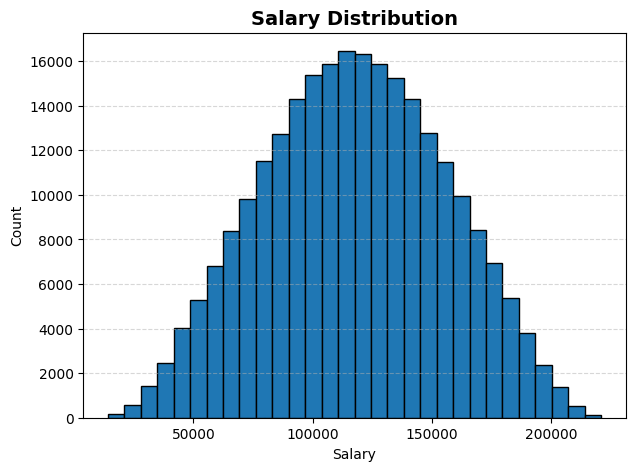

In [21]:
plt.figure(figsize=(7,5))

plt.hist(df['salary'], bins=30, edgecolor='black', linewidth=1)

plt.title("Salary Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Salary")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

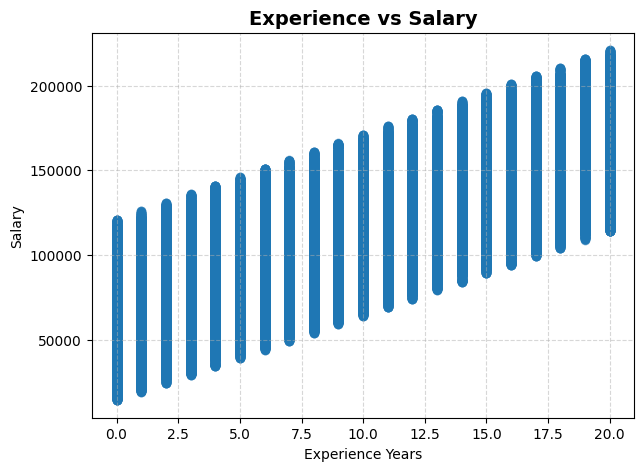

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(df['experience_years'], df['salary'], alpha=0.6)

plt.xlabel("Experience Years")
plt.ylabel("Salary")

plt.title("Experience vs Salary", fontsize=14, fontweight='bold')

plt.grid(linestyle='--', alpha=0.5)

plt.show()

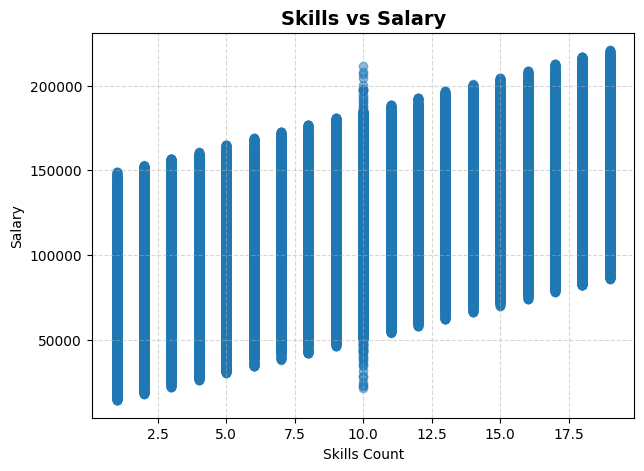

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(df['skills_count'], df['salary'], alpha=0.5)

plt.xlabel("Skills Count")
plt.ylabel("Salary")
plt.title("Skills vs Salary", fontsize=14, fontweight='bold')

plt.grid(linestyle='--', alpha=0.5)

plt.show()

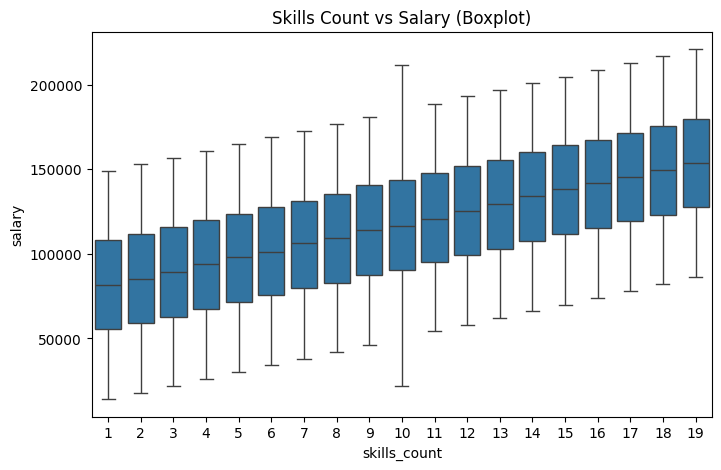

In [24]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x='skills_count', y='salary', data=df)

plt.title("Skills Count vs Salary (Boxplot)")

plt.show()

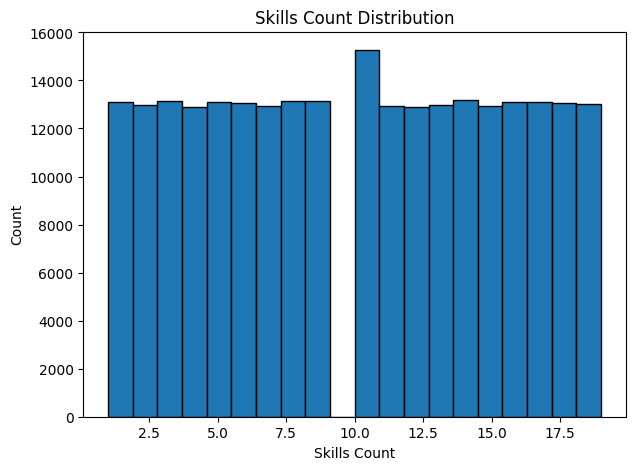

In [25]:
plt.figure(figsize=(7,5))

plt.hist(df['skills_count'], bins=20, edgecolor='black')

plt.title("Skills Count Distribution")

plt.xlabel("Skills Count")
plt.ylabel("Count")

plt.show()

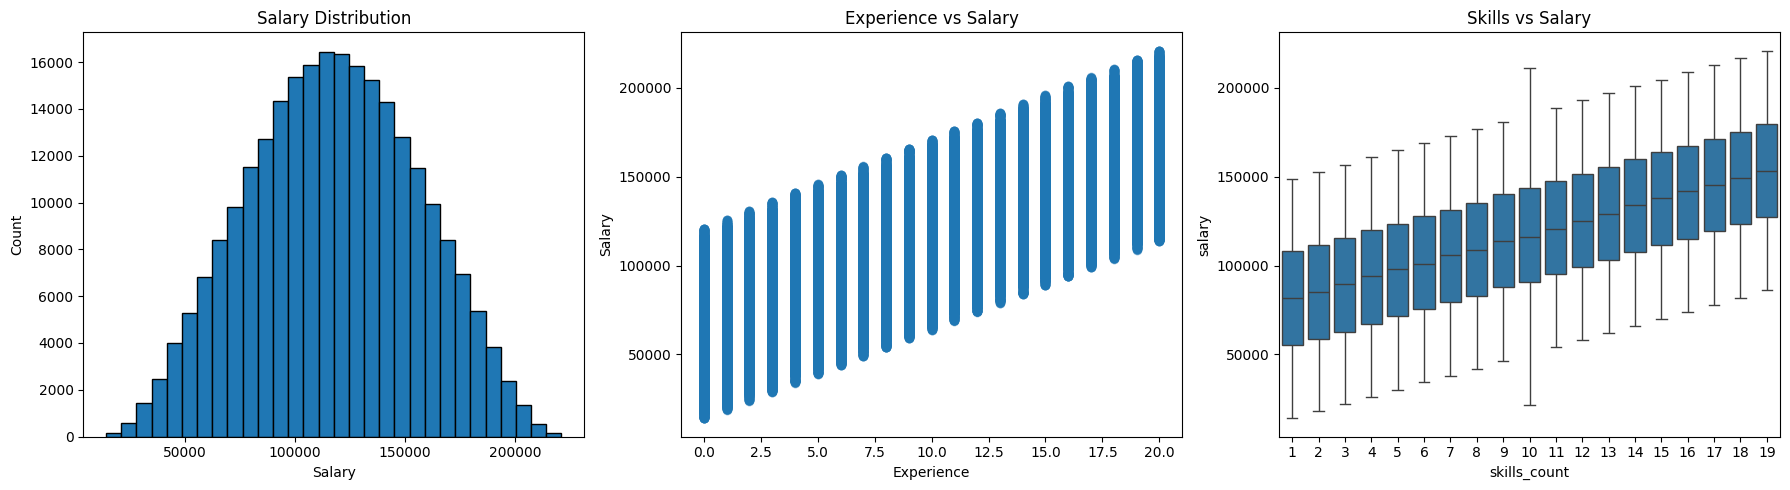

In [26]:
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18,5))

# 1️⃣ Histogram (Matplotlib)
ax[0].hist(df['salary'], bins=30, edgecolor='black')
ax[0].set_title("Salary Distribution")
ax[0].set_xlabel("Salary")
ax[0].set_ylabel("Count")

# 2️⃣ Scatter (Matplotlib)
ax[1].scatter(df['experience_years'], df['salary'], alpha=0.5)
ax[1].set_title("Experience vs Salary")
ax[1].set_xlabel("Experience")
ax[1].set_ylabel("Salary")

# 3️⃣ Boxplot (Seaborn)
sns.boxplot(x='skills_count', y='salary', data=df, ax=ax[2])
ax[2].set_title("Skills vs Salary")

plt.tight_layout()
plt.show()

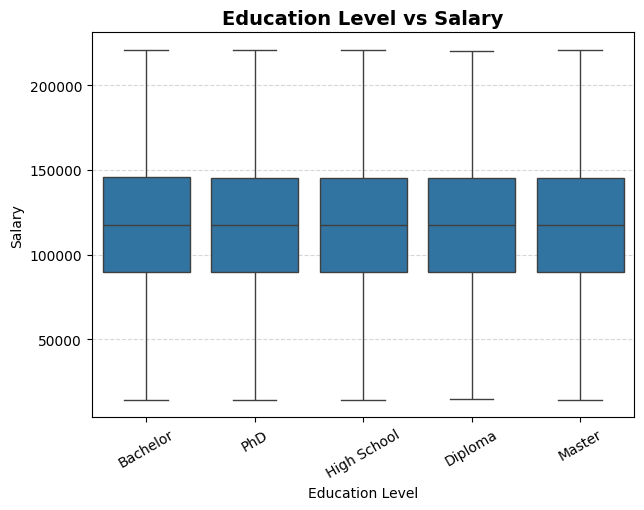

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.boxplot(x='education_level', y='salary', data=df)

plt.title("Education Level vs Salary", fontsize=14, fontweight='bold')
plt.xlabel("Education Level")
plt.ylabel("Salary")

plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

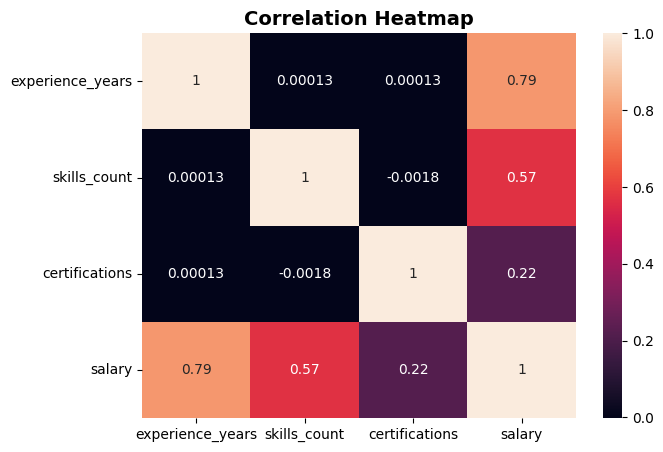

In [28]:
plt.figure(figsize=(7,5))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')

plt.show()

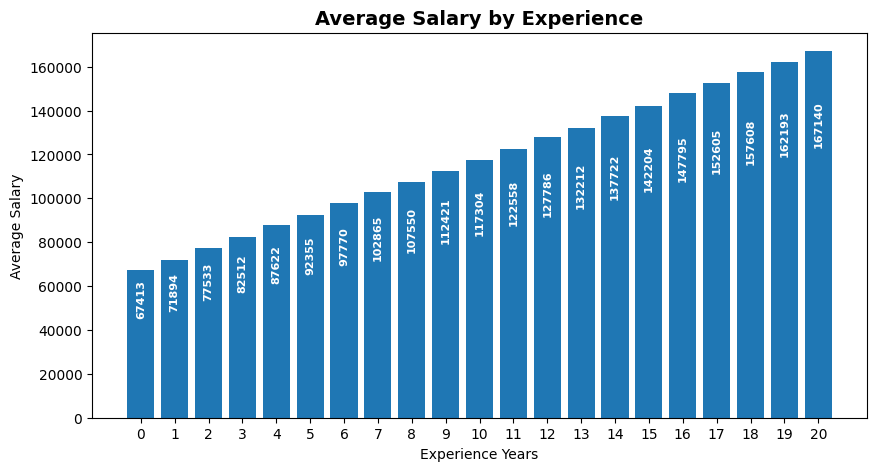

In [29]:
import matplotlib.pyplot as plt

# Group data
avg_salary = df.groupby('experience_years')['salary'].mean()

plt.figure(figsize=(10,5))

bars = plt.bar(avg_salary.index, avg_salary.values)

plt.title("Average Salary by Experience", fontsize=14, fontweight='bold')
plt.xlabel("Experience Years")
plt.ylabel("Average Salary")

# ✅ Fix ticks
plt.xticks(avg_salary.index)

# 🔥 Add values inside bars
for bar in bars:
    yval = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval * 0.8,   # inside bar
        int(yval),
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold',
        rotation=90
    )

plt.show()

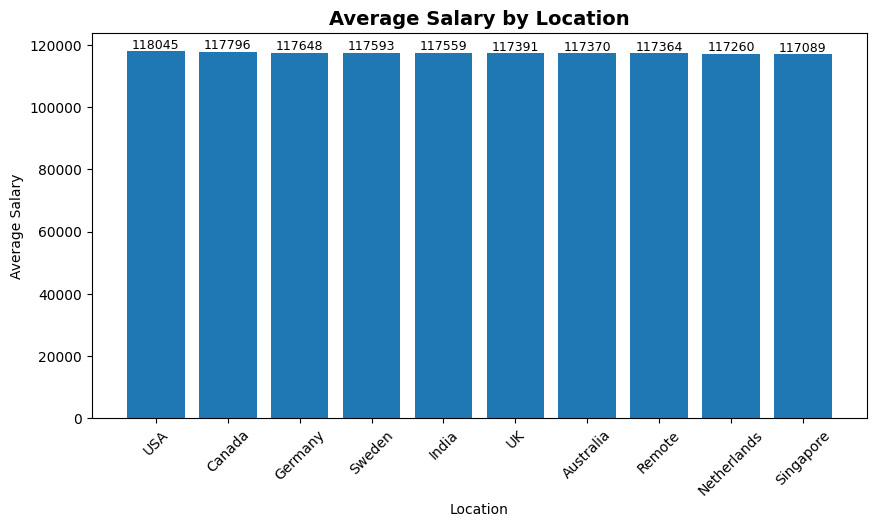

In [30]:
import matplotlib.pyplot as plt

# Calculate average salary
avg_salary = df.groupby('location')['salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

bars = plt.bar(avg_salary.index, avg_salary.values)

plt.title("Average Salary by Location", fontsize=14, fontweight='bold')
plt.xlabel("Location")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

# 🔥 Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), 
             ha='center', va='bottom', fontsize=9)

plt.show()

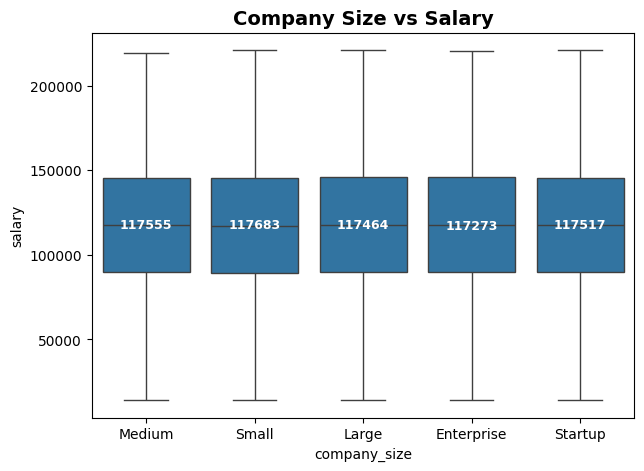

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

ax = sns.boxplot(x='company_size', y='salary', data=df)

plt.title("Company Size vs Salary", fontsize=14, fontweight='bold')

# 🔥 Add median values inside each box
medians = df.groupby('company_size')['salary'].median()

for i, (cat, median) in enumerate(medians.items()):
    plt.text(
        i, 
        median, 
        int(median),
        ha='center',
        va='center',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

plt.show()

In [36]:
df_sample = df.sample(n=50000, random_state=42)  # reduce size

X = df_sample.drop('salary', axis=1)
y = df_sample['salary']

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
print(X.corrwith(y).sort_values(ascending=False))

experience_years                       0.786608
skills_count                           0.571255
certifications                         0.219391
job_title_Data Scientist               0.007981
education_level_High School            0.007327
location_Canada                        0.006154
job_title_Data Analyst                 0.005743
industry_Technology                    0.005693
location_Sweden                        0.004679
industry_Education                     0.004612
location_USA                           0.004158
job_title_Cybersecurity Analyst        0.003933
company_size_Large                     0.003886
education_level_Master                 0.003311
job_title_Business Analyst             0.002991
job_title_Software Engineer            0.002485
company_size_Startup                   0.002186
remote_work_No                         0.002160
industry_Media                         0.001980
industry_Telecom                       0.001871
industry_Government                    0

In [38]:
# =========================
# IMPORT LIBRARIES
# =========================
import pickle
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# TRAIN MODEL
# =========================
knn = KNeighborsRegressor(n_neighbors=3)

knn.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = knn.predict(X_test)

# =========================
# EVALUATION
# =========================
print("🔹 KNN Model Performance")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# =========================
# SAVE MODEL
# =========================
pickle.dump(knn, open("knn_model.pkl", "wb"))

🔹 KNN Model Performance
R2 Score: 0.9852710762603387
MAE: 3651.4878333333336
MSE: 21586743.426944446


In [40]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# =========================
# REDUCE SIZE (OPTIONAL)
# =========================
df = df.sample(n=50000, random_state=42)

# =========================
# FEATURE ENGINEERING
# =========================
df['exp_squared'] = df['experience_years'] ** 2
df['skill_per_exp'] = df['skills_count'] / (df['experience_years'] + 1)
df['cert_per_skill'] = df['certifications'] / (df['skills_count'] + 1)

df['seniority'] = pd.cut(
    df['experience_years'],
    bins=[0, 2, 5, 10, 20],
    labels=['Fresher', 'Junior', 'Mid', 'Senior']
)

# =========================
# ENCODING
# =========================
cat_cols = ['job_title', 'education_level', 'location', 'industry',
            'company_size', 'remote_work', 'seniority']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# =========================
# FEATURES & TARGET
# =========================
X = df.drop('salary', axis=1)
y = df['salary']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# SCALING (NUMERIC ONLY)
# =========================
num_cols = ['experience_years', 'skills_count', 'certifications',
            'exp_squared', 'skill_per_exp', 'cert_per_skill']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# =========================
# TRAIN KNN
# =========================
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
y_pred = knn.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("🔹 Model Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

# =========================
# SAVE EVERYTHING
# =========================
pickle.dump(knn, open("knn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("✅ Model ready for deployment!")

🔹 Model Performance
R2 Score: 0.9550428109051353
MAE: 6450.773585714286
MSE: 65889356.43506735
✅ Model ready for deployment!


In [41]:
print(X.corrwith(y).sort_values(ascending=False))

experience_years                       0.786608
exp_squared                            0.757928
seniority_Senior                       0.679028
skills_count                           0.571255
certifications                         0.219391
job_title_Data Scientist               0.007981
education_level_High School            0.007327
location_Canada                        0.006154
job_title_Data Analyst                 0.005743
industry_Technology                    0.005693
location_Sweden                        0.004679
industry_Education                     0.004612
location_USA                           0.004158
job_title_Cybersecurity Analyst        0.003933
company_size_Large                     0.003886
education_level_Master                 0.003311
job_title_Business Analyst             0.002991
job_title_Software Engineer            0.002485
company_size_Startup                   0.002186
remote_work_No                         0.002160
industry_Media                         0

In [42]:
df

,experience_years,skills_count,certifications,salary,exp_squared,skill_per_exp,cert_per_skill,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,...,industry_Telecom,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup,remote_work_No,remote_work_Yes,seniority_Junior,seniority_Mid,seniority_Senior
38683,10,7,3.0,112084,100,0.636364,0.375000,False,False,False,...,True,False,False,False,True,False,False,False,True,False
64939,10,14,1.0,130879,100,1.272727,0.066667,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3954,10,2,5.0,94776,100,0.181818,1.666667,False,False,False,...,False,False,False,False,True,False,True,False,True,False
120374,10,9,4.0,122480,100,0.818182,0.400000,False,False,False,...,False,False,True,False,False,True,False,False,True,False
172861,2,12,4.0,94748,4,4.000000,0.307692,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179545,12,4,4.0,115474,144,0.307692,0.800000,False,False,False,...,False,False,False,False,True,False,True,False,False,True
222647,14,6,1.0,113886,196,0.400000,0.142857,False,False,False,...,False,False,False,True,False,False,False,False,False,True
171823,13,11,5.0,144728,169,0.785714,0.416667,False,False,False,...,False,True,False,False,False,False,True,False,False,True
135782,15,17,1.0,165098,225,1.062500,0.055556,False,False,False,...,False,False,False,True,False,False,False,False,False,True
